In [12]:
"""
Advanced Exploratory Data Analysis (EDA) for Causal Cloud Metrics.
Validates the "Four Golden Signals" physics and anomaly profiles.
"""

import matplotlib.pyplot as plt
import pandas as pd


print("Loading synthetic metrics...")
df = pd.read_csv('../data/raw/synthetic_metrics.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Find the exact start and end indices of distinct incidents
df['incident_start'] = (df['is_incident'] == 1) & (df['is_incident'].shift(1) == 0)
df['incident_end'] = (df['is_incident'] == 0) & (df['is_incident'].shift(1) == 1)

incident_start_times = df[df['incident_start']].index
incident_end_times = df[df['incident_end']].index

num_features = len([c for c in df.columns if c.startswith('metric_')])

print(f"Dataset Shape: {df.shape}")
print(f"Total Features Generated: {num_features}")
print(f"Total Distinct Incidents Found: {len(incident_start_times)}")

plt.style.use('seaborn-v0_8-darkgrid')

Loading synthetic metrics...
Dataset Shape: (500000, 8)
Total Features Generated: 5
Total Distinct Incidents Found: 493


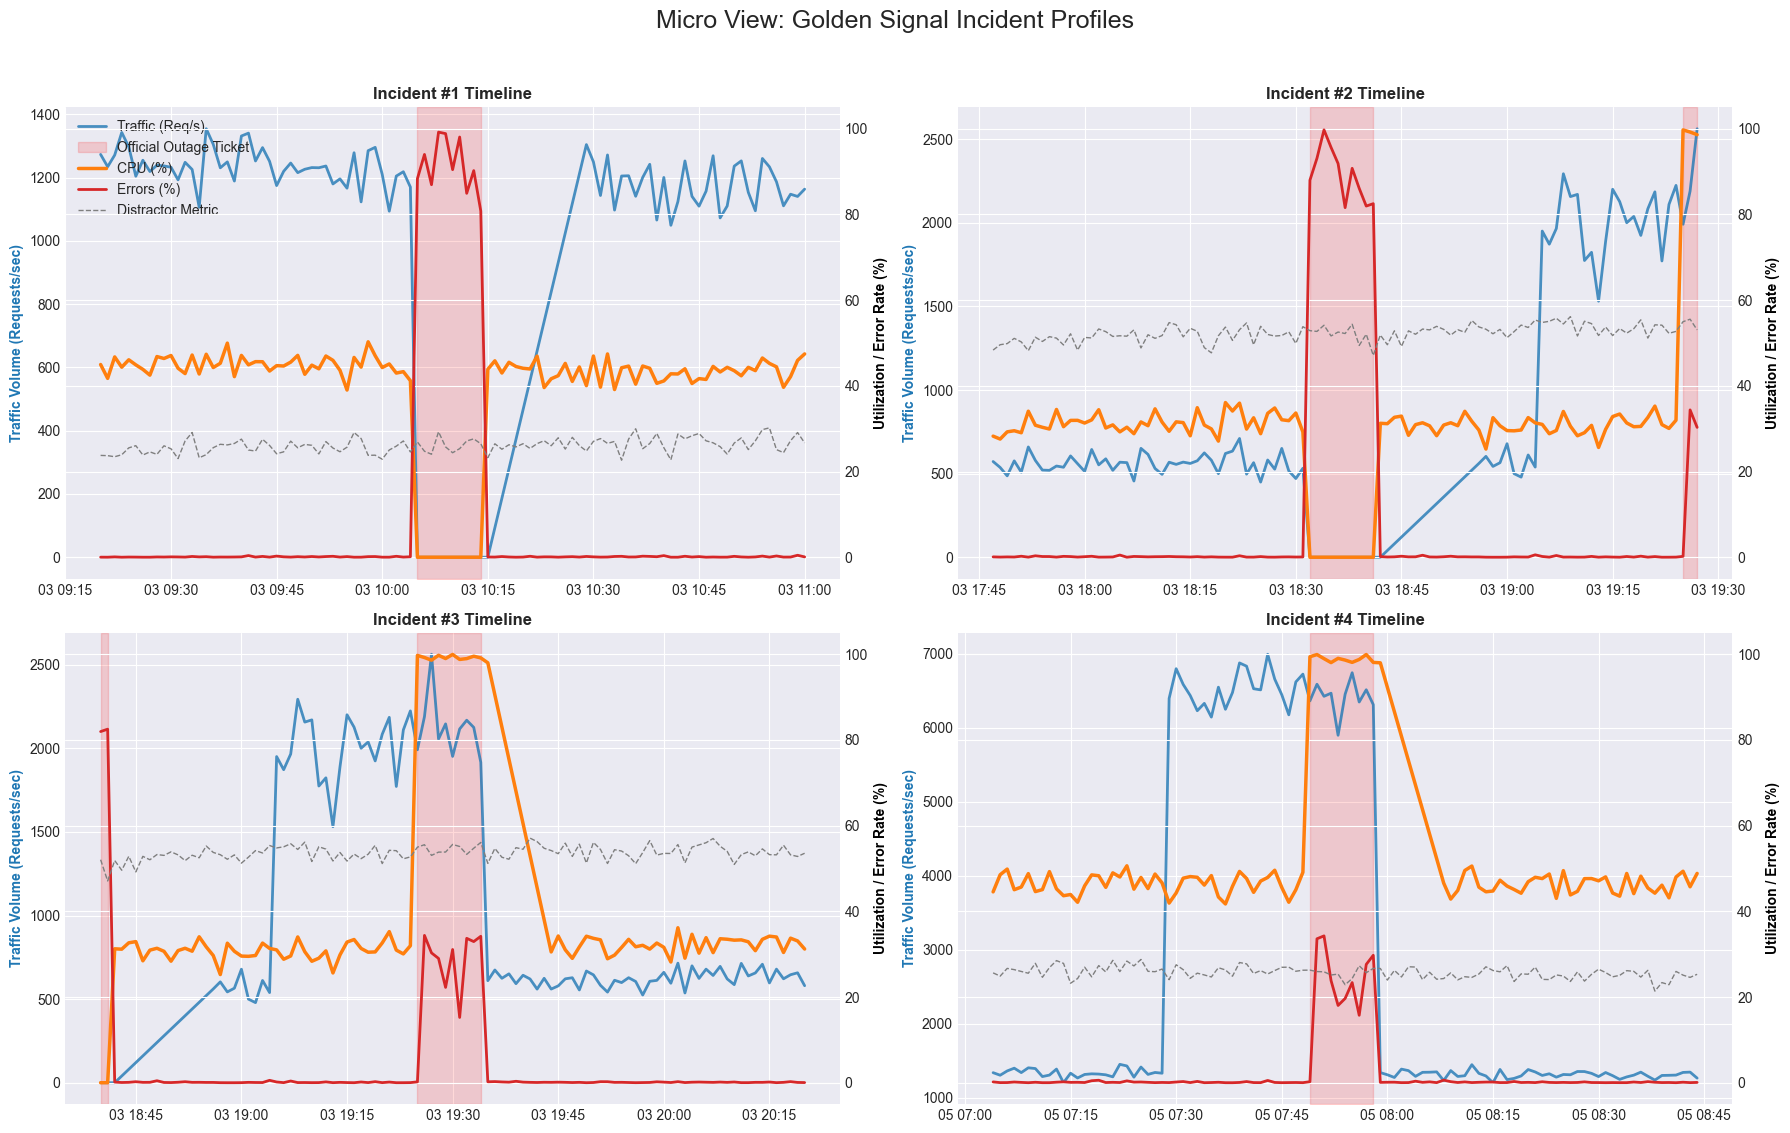

In [13]:
# ==========================================
# Plot 1: The Causal Incident Gallery (Micro Views)
# ==========================================
# We use twin axes here because Traffic (metric_0) is in the thousands,
# while CPU (metric_1) and Errors (metric_2) are 0-100 percentages.

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Micro View: Golden Signal Incident Profiles', fontsize=18, y=0.97)

axes = axes.flatten()

for i in range(min(4, len(incident_start_times))):
    start_time = incident_start_times[i]
    end_time = incident_end_times[i] if i < len(incident_end_times) else df.index[-1]

    # Grab a window: 45 minutes before and after to see the leading indicators
    window_start = start_time - pd.Timedelta(minutes=45)
    window_end = end_time + pd.Timedelta(minutes=45)
    zoom_df = df.loc[window_start:window_end]

    ax_left = axes[i]
    ax_right = ax_left.twinx()  # Create a secondary y-axis

    # Plot Traffic on the Left Axis
    if 'metric_0' in zoom_df.columns:
        line1 = ax_left.plot(zoom_df.index, zoom_df['metric_0'], label='Traffic (Req/s)', color='#1f77b4', linewidth=2, alpha=0.8)

    # Plot CPU, Errors, and Distractors on the Right Axis
    lines_right = []
    if 'metric_1' in zoom_df.columns:
        lines_right += ax_right.plot(zoom_df.index, zoom_df['metric_1'], label='CPU (%)', color='#ff7f0e', linewidth=2.5)
    if 'metric_2' in zoom_df.columns:
        lines_right += ax_right.plot(zoom_df.index, zoom_df['metric_2'], label='Errors (%)', color='#d62728', linewidth=2)
    if 'metric_3' in zoom_df.columns:
        lines_right += ax_right.plot(zoom_df.index, zoom_df['metric_3'], label='Distractor Metric', color='#7f7f7f', linewidth=1, linestyle='--')

    # Highlight the official incident window
    ax_left.fill_between(
        zoom_df.index, 0, 1,
        where=(zoom_df['is_incident'] == 1),
        color='red', alpha=0.15, transform=ax_left.get_xaxis_transform(),
        label='Official Outage Ticket'
    )

    ax_left.set_title(f'Incident #{i+1} Timeline', fontsize=12, fontweight='bold')
    ax_left.set_ylabel('Traffic Volume (Requests/sec)', color='#1f77b4', fontweight='bold')
    ax_right.set_ylabel('Utilization / Error Rate (%)', color='black', fontweight='bold')
    ax_right.set_ylim(-5, 105) # Lock the right axis to percentage

    # Combine legends cleanly for the first chart
    if i == 0:
        lines_left, labels_left = ax_left.get_legend_handles_labels()
        lines_right, labels_right = ax_right.get_legend_handles_labels()
        ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


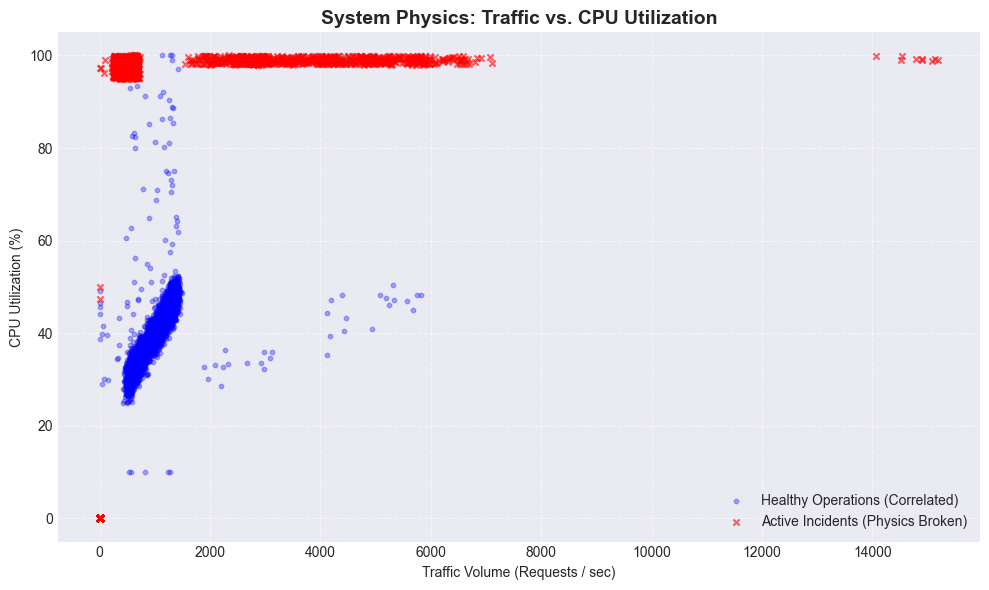

In [14]:
# ==========================================
# Plot 2: Breaking the Physics (Correlation Analysis)
# ==========================================
# In a healthy system, CPU is a function of Traffic.
# During an anomaly (like a memory leak), this relationship breaks down.
# This plot visualizes the exact "pattern" the ML model learns to detect.

if 'metric_0' in df.columns and 'metric_1' in df.columns:
    plt.figure(figsize=(10, 6))

    # Separate healthy data from incident data
    normal_df = df[df['is_incident'] == 0]
    incident_df = df[df['is_incident'] == 1]

    # We plot a sample to avoid overcrowding the scatter plot
    sample_normal = normal_df.sample(n=min(5000, len(normal_df)), random_state=42)
    sample_incident = incident_df.sample(n=min(2000, len(incident_df)), random_state=42)

    plt.scatter(sample_normal['metric_0'], sample_normal['metric_1'],
                alpha=0.3, color='blue', label='Healthy Operations (Correlated)', s=10)

    plt.scatter(sample_incident['metric_0'], sample_incident['metric_1'],
                alpha=0.6, color='red', label='Active Incidents (Physics Broken)', s=20, marker='x')

    plt.title('System Physics: Traffic vs. CPU Utilization', fontsize=14, fontweight='bold')
    plt.xlabel('Traffic Volume (Requests / sec)')
    plt.ylabel('CPU Utilization (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()